In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme("paper")
sns.set_style("whitegrid")

plt.rc("font", size=10)

text_width = 107.0 / 25.4
margin_width = 47.5 / 25.4
wide_width = 160.0 / 25.4

In [3]:
# load smith pure water
smith = np.loadtxt("water_smith81.csv", delimiter=",", skiprows=1)

In [4]:
# straw attenuation lengths
straw = np.array([
    # lambda, mu_t, +err, -err
    [365.0, 1.0 / 10.4, 1.0 / (10.4 + 0.4), 1.0 / (10.4 - 0.3)],
    [400.0, 1.0 / 14.6, 1.0 / (14.6 + 0.4), 1.0 / (14.6 - 0.6)],
    [450.0, 1.0 / 27.7, 1.0 / (27.7 + 1.9), 1.0 / (27.7 - 1.3)],
    [585.0, 1.0 / 7.1, 1.0 / (7.1 + 0.4), 1.0 / (7.1 - 0.3)],
])
straw_err = np.abs(straw[:,2:] - straw[:,1][:,None])

np.set_printoptions(4, suppress=True)
print(straw)

[[365.       0.0962   0.0926   0.099 ]
 [400.       0.0685   0.0667   0.0714]
 [450.       0.0361   0.0338   0.0379]
 [585.       0.1408   0.1333   0.1471]]


I failed in fitting a spectrum of mu_a and mu_s.
So let's do an educated guess instead:

- interpolate attenuation to 530.0nm
- assume mu_s : mu_s = 25 : 75
- scale mu_s from Petzold Station 9 accordingly
- calculate nu_s, nu_l to form the complete mu_s spectrum
- fit exponential on residual attenuation length m_t - mu_s - smith(mu_a)

In [5]:
att_550nm = np.interp(550.0, straw[:,0], straw[:,1])
att_550nm

np.float64(0.11368922183993116)

In [6]:
# mu_s_550nm = 0.25 * att_550nm
# mu_a_550nm = 0.75 * att_550nm

r = 0.135

mu_s_550nm = r * att_550nm
# mu_a_550nm = 0.90 * att_550nm

In [7]:
mu_s_petzold = 0.043
mu_s_scale = mu_s_550nm / mu_s_petzold
mu_s_scale

np.float64(0.35693127786955137)

In [8]:
petzold_1deg = 2.9964E+00
petzold_45deg = 1.4354E-03

mu_s_1deg = petzold_1deg * mu_s_scale
mu_s_45deg = petzold_45deg * mu_s_scale

print(mu_s_1deg)
print(mu_s_45deg)

1.0695088810083238
0.0005123391562539541


In [9]:
nu_s = -1.4e-4 * mu_s_1deg + 10.2 * mu_s_45deg - 0.002
nu_l = 2.2e-2 * mu_s_1deg - 1.2 * mu_s_45deg

print(nu_s)
print(nu_l)

0.003076128150449166
0.022914388394678378


In [10]:
def mu_s_kop(lam, nu_s, nu_l):
    x = 550.0 / lam
    return 0.0017*np.float_power(x, 4.3) + \
        1.34*nu_s*np.float_power(x,1.7) + \
        0.312*nu_l*np.float_power(x,0.3)

In [11]:
mu_a_res = straw[:,1] - mu_s_kop(straw[:,0], nu_s, nu_l) - np.interp(straw[:,0], smith[:,0], smith[:,1])
mu_a_res

array([ 0.0359,  0.0298,  0.0042, -0.0037])

In [12]:
mu_a_res_up = straw[:,3] - mu_s_kop(straw[:,0], nu_s, nu_l) - np.interp(straw[:,0], smith[:,0], smith[:,1])
mu_a_res_up

array([0.0388, 0.0327, 0.006 , 0.0025])

In [13]:
from scipy.optimize import curve_fit

def fit_exp(x, a, b):
    return a * np.exp(-b*(x-550.0))

popt, pcov = curve_fit(
    fit_exp, straw[:,0], mu_a_res,
    bounds=(0.0, np.inf),
    p0=(0.0028, 0.0145),
    sigma=straw_err[:,1],
    absolute_sigma=True,
)
popt

array([0.0012, 0.0188])

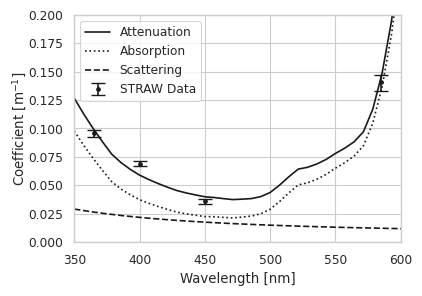

In [14]:
x = np.linspace(350.0, 700.0)

# plt.figure()
plt.figure(figsize=(text_width, 0.7*text_width))
# plt.title(f"Ratio $\\mu_s(550nm)$ = {r}")
plt.errorbar(
    straw[:,0], straw[:,1],
    yerr=np.abs(straw[:,2:] - straw[:,1][:,None]).T,
    fmt='.', capsize=5, color="k",
    label="STRAW Data"    
)
# plt.plot(x, mu_s_kop(x, nu_s, nu_l) + np.interp(x, smith[:,0], smith[:,1]))
plt.plot(x,
    mu_s_kop(x, nu_s, nu_l) + np.interp(x, smith[:,0], smith[:,1]) + fit_exp(x, *popt),
    color="k", label="Attenuation")
plt.plot(x,
    np.interp(x, smith[:,0], smith[:,1]) + fit_exp(x, *popt),
    "k:", label="Absorption")
plt.plot(x, mu_s_kop(x, nu_s, nu_l), "k--", label="Scattering")
# plt.plot(smith[:,0], smith[:,2], "k-.")
plt.xlim(350.0, 600)
plt.ylim(0.0, 0.2)
plt.ylabel("Coefficient [m$^{-1}$]", labelpad=0)
plt.xlabel("Wavelength [nm]")
plt.legend()
# plt.savefig("../images/water_model.pdf", bbox_inches='tight', pad_inches=0)
plt.show()

In [ ]:
# calculate actual ratio at 550nm
l = 532.0
mu_tot = mu_s_kop(l, nu_s, nu_l) + np.interp(l, smith[:,0], smith[:,1]) + fit_exp(l, *popt)
mu_s_kop(l, nu_s, nu_l) / mu_tot

Let's finally try to fit the ratio, too.

In [ ]:
# def fit(x, r, a, b):
#     mu_s_550nm = r * att_550nm
#     mu_a_550nm = (1.0 - r) * att_550nm
#     mu_s_scale = mu_s_550nm / mu_s_petzold

#     mu_s_1deg = petzold_1deg * mu_s_scale
#     mu_s_45deg = petzold_45deg * mu_s_scale
#     nu_s = -1.4e-4 * mu_s_1deg + 10.2 * mu_s_45deg - 0.002
#     nu_l = 2.2e-2 * mu_s_1deg - 1.2 * mu_s_45deg

#     mu_s = mu_s_kop(x, nu_s, nu_l)
#     mu_a = np.interp(x, smith[:,0], smith[:,1])
#     mu_a += a * np.exp(-b * (x - 550.0))

#     return mu_s + mu_a

# popt, pcov = curve_fit(
#     fit, straw[:,0], mu_a_res,
#     bounds=((1e-4, 0.0, 0.0), (1.0, np.inf, np.inf)),
#     p0=(0.18, 0.0028, 0.0145),
# )
# popt

Didn't work. Always pulls mu_s to zero.

Let's finally create a serialized medium for easier use.

In [ ]:
petzold = np.loadtxt("../data/petzold.csv", delimiter=" ", skiprows=1)
petzold_mus = petzold[-1,3]

petzold_log_phase = np.log(petzold[:,2] / petzold_mus)

In [ ]:
from numpy._typing import NDArray
import theia
import theia.material

class WaterModel(
    theia.material.WaterBaseModel,
    theia.material.KokhanovskyOceanWaterPhaseMatrix,
    theia.material.MediumModel,
):
    def __init__(self) -> None:
        theia.material.WaterBaseModel.__init__(self, 4.0, 2900.0, 35.0)
        theia.material.KokhanovskyOceanWaterPhaseMatrix.__init__(
            self, p90=0.66, theta0=0.25, alpha=4.0, xi=25.6  # voss measurement fit
        )
    ModelName = "water"
    
    def scattering_coef(self, wavelength):
        return mu_s_kop(wavelength, nu_s, nu_l)
    
    def absorption_coef(self, wavelength):
        return np.interp(wavelength, smith[:,0], smith[:,1]) + fit_exp(wavelength, *popt)
    
    def log_phase_function(self, cos_theta):
        return np.interp(cos_theta, np.cos(petzold[:,0])[::-1], petzold_log_phase[::-1])
    
    def phase_sampling(self, eta):
        return np.interp(eta, petzold[:,4], np.cos(petzold[:,0]))

model = WaterModel()

In [ ]:
l = np.linspace(0.1,180.0, 512)
r = np.deg2rad(l)

plt.figure()
plt.plot(l, np.exp(model.log_phase_function(np.cos(r))))
plt.plot(petzold[:,1], petzold[:,2])
plt.plot(petzold[:,1], np.exp(petzold_log_phase))
plt.xscale("log")
plt.yscale("log")
plt.show()

In [ ]:
from scipy.integrate import quad

def foo(x):
    return np.exp(model.log_phase_function(x)) #* petzold_mus / 0.04200940673072452

quad(foo, -1, +1, limit=1000)[0] * 2.0 * np.pi

In [ ]:
from scipy.optimize import curve_fit


def ffoo(x, n, mu):
    ff = theia.material.FournierForandPhaseFunction(n, mu)
    return ff.log_phase_function(x)

_popt, _pcov = curve_fit(ffoo, np.cos(petzold[:,0]), petzold_log_phase, p0=(1.175, 4.065))
_popt

In [ ]:
ff = theia.material.FournierForandPhaseFunction(*_popt)

plt.figure()
plt.plot(l, np.exp(model.log_phase_function(np.cos(r))))
plt.plot(l, np.exp(ff.log_phase_function(np.cos(r))))
plt.xscale("log")
plt.yscale("log")
plt.show()

In [ ]:
u = np.linspace(0.0, 1.0)

plt.figure()
plt.plot(u, model.phase_sampling(u))
plt.plot(u, ff.phase_sampling(u))
# plt.yscale("log")
plt.show()

In [ ]:
x = np.linspace(350.0, 700.0)

# plt.figure()
plt.figure(figsize=(text_width, 0.7*text_width))
# plt.title(f"Ratio $\\mu_s(550nm)$ = {r}")
plt.errorbar(
    straw[:,0], straw[:,1],
    yerr=np.abs(straw[:,2:] - straw[:,1][:,None]).T,
    fmt='.', capsize=5, color="k",
    label="$\\mu_t$ STRAW"    
)
# plt.plot(x, mu_s_kop(x, nu_s, nu_l) + np.interp(x, smith[:,0], smith[:,1]))
plt.plot(x, model.absorption_coef(x) + model.scattering_coef(x), label="$\\mu_t$")
plt.plot(x, model.absorption_coef(x), label="$\\mu_a$")
plt.plot(x, model.scattering_coef(x), "k--", label="$\\mu_s$")
# plt.plot(smith[:,0], smith[:,2], "k-.")
plt.xlim(350.0, 600)
plt.ylim(0.0, 0.2)
plt.ylabel("Coefficient [m$^{-1}$]", labelpad=0)
plt.xlabel("Wavelength [nm]")
plt.legend()
plt.show()

In [ ]:
import theia.units


plt.figure()
plt.plot(x, model.refractive_index(x))
plt.plot(x, 1.0 * theia.units.c / model.group_velocity(x))
plt.show()

Everything looks fine -> save it

In [ ]:
model.createMedium().save("../data/water_model")

Finally, we also need the amount of Cherenkov photons produced per meter.
Since this depends on the refractive index, we'll do this here.

In [ ]:
from theia.light import frankTamm
from scipy.integrate import quad

# calculate for different wavelength ranges
print(quad(lambda x: frankTamm(x, model.refractive_index(x)), 270.0, 700.0))
print(quad(lambda x: frankTamm(x, model.refractive_index(x)), 280.0, 620.0))
print(quad(lambda x: frankTamm(x, model.refractive_index(x)), 300.0, 600.0))

| $\lambda$ [nm] | $\frac{d^2N}{dx d\lambda}$ [$m^{-1}$] |
|----------------|-------------------------------------|
| 270.0 - 700.0  | 47803.9 |
| 280.0 - 620.0  | 41150.1 |
| 300.0 - 600.0  | 34897.5 |